
# Ball detection on a differential video

This notebook detects likely tennis-ball locations from a **differential video** where most of the frame is dark and moving objects appear bright.

It includes:
- small, debug-friendly functions
- single-frame candidate detection
- optional allowed-area restriction
- full-video export with the **top 5 guesses** drawn on each frame

The detector uses:
1. grayscale thresholding
2. connected components
3. size filtering using an **estimated ball diameter in pixels**
4. shape filtering to reject large player blobs and elongated regions
5. ranking by brightness and shape consistency


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:

def get_video_info(video_path: str) -> dict:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    info = {
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": float(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()
    return info


def read_video_frame(video_path: str, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        raise ValueError(f"Could not read frame {frame_idx} from {video_path}")

    return frame


def to_gray(frame: np.ndarray) -> np.ndarray:
    if frame.ndim == 2:
        return frame
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)


In [3]:

def make_allowed_mask(
    frame_shape,
    polygon=None,
    rect=None,
    binary_mask=None,
):
    """
    Build a uint8 mask with 255 in allowed regions and 0 elsewhere.

    Parameters
    ----------
    frame_shape : tuple
        Shape of the frame, e.g. gray.shape or frame.shape[:2].
    polygon : array-like of shape (N, 2), optional
        Polygon vertices in (x, y) image coordinates.
    rect : tuple, optional
        (x_min, y_min, x_max, y_max)
    binary_mask : np.ndarray, optional
        Existing binary mask. Nonzero values are treated as allowed.
    """
    h, w = frame_shape[:2]
    mask = np.ones((h, w), dtype=np.uint8) * 255

    if binary_mask is not None:
        m = (binary_mask > 0).astype(np.uint8) * 255
        if m.shape != (h, w):
            raise ValueError(f"binary_mask has shape {m.shape}, expected {(h, w)}")
        mask = cv2.bitwise_and(mask, m)

    if rect is not None:
        x0, y0, x1, y1 = map(int, rect)
        rect_mask = np.zeros((h, w), dtype=np.uint8)
        rect_mask[max(0, y0):min(h, y1), max(0, x0):min(w, x1)] = 255
        mask = cv2.bitwise_and(mask, rect_mask)

    if polygon is not None:
        poly_mask = np.zeros((h, w), dtype=np.uint8)
        pts = np.asarray(polygon, dtype=np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(poly_mask, [pts], 255)
        mask = cv2.bitwise_and(mask, poly_mask)

    return mask


def apply_allowed_mask(gray_frame: np.ndarray, allowed_mask: np.ndarray | None) -> np.ndarray:
    if allowed_mask is None:
        return gray_frame
    return cv2.bitwise_and(gray_frame, gray_frame, mask=allowed_mask)


In [4]:

def threshold_motion(
    gray_diff: np.ndarray,
    diff_thresh: int = 25,
    blur_ksize: int = 0,
    morph_open: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert a grayscale differential frame into a binary foreground mask.

    Returns
    -------
    proc_gray : np.ndarray
        Preprocessed grayscale frame actually thresholded.
    binary : np.ndarray
        Binary mask (0 or 255).
    """
    proc = gray_diff.copy()

    if blur_ksize and blur_ksize > 1:
        if blur_ksize % 2 == 0:
            blur_ksize += 1
        proc = cv2.GaussianBlur(proc, (blur_ksize, blur_ksize), 0)

    _, binary = cv2.threshold(proc, diff_thresh, 255, cv2.THRESH_BINARY)

    if morph_open and morph_open > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_open, morph_open))
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    return proc, binary


In [5]:

def component_circularity(component_mask: np.ndarray) -> float:
    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if perimeter <= 0:
        return 0.0

    return float((4.0 * np.pi * area) / (perimeter * perimeter))


def expected_ball_area(ball_diameter_px: float) -> float:
    r = ball_diameter_px / 2.0
    return float(np.pi * r * r)


In [20]:

def extract_ball_candidates(
    gray_diff: np.ndarray,
    ball_diameter_px: float,
    diff_thresh: int = 25,
    allowed_mask: np.ndarray | None = None,
    blur_ksize: int = 0,
    morph_open: int = 0,
    min_area_scale: float = 0.20,
    max_area_scale: float = 2.50,
    min_circularity: float = 0.20,
    max_aspect_ratio_deviation: float = 0.90,
    max_bbox_scale: float = 2.25,
    min_mean_brightness: float = 0.0,
):
    """
    Detect connected components that look like a small bright ball.

    Returns a list of candidate dicts sorted best-first.
    """
    gray = to_gray(gray_diff)
    gray = apply_allowed_mask(gray, allowed_mask)
    proc_gray, binary = threshold_motion(
        gray,
        diff_thresh=diff_thresh,
        blur_ksize=blur_ksize,
        morph_open=morph_open,
    )

    nlabels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    target_area = expected_ball_area(ball_diameter_px)
    min_area = min_area_scale * target_area
    max_area = max_area_scale * target_area
    max_bbox_size = max_bbox_scale * ball_diameter_px

    candidates = []

    for label in range(1, nlabels):
        x = int(stats[label, cv2.CC_STAT_LEFT])
        y = int(stats[label, cv2.CC_STAT_TOP])
        w = int(stats[label, cv2.CC_STAT_WIDTH])
        h = int(stats[label, cv2.CC_STAT_HEIGHT])
        area = int(stats[label, cv2.CC_STAT_AREA])
        cx, cy = centroids[label]

        if area < min_area or area > max_area:
            continue

        if w > max_bbox_size or h > max_bbox_size:
            continue

        aspect_ratio = w / max(h, 1)
        if abs(aspect_ratio - 1.0) > max_aspect_ratio_deviation:
            continue

        component_mask = np.zeros_like(binary)
        component_mask[labels == label] = 255
        circularity = component_circularity(component_mask)
        if circularity < min_circularity:
            continue

        ys, xs = np.where(labels == label)
        values = proc_gray[ys, xs]
        mean_brightness = float(values.mean()) if values.size else 0.0
        max_brightness = int(values.max()) if values.size else 0

        if mean_brightness < min_mean_brightness:
            continue

        size_error = abs(area - target_area) / max(target_area, 1e-6)
        brightness_score = mean_brightness / 255.0
        circularity_score = circularity
        size_score = max(0.0, 1.0 - size_error)
        score = 0.60 * brightness_score + 0.20 * circularity_score + 0.20 * size_score

        candidates.append({
            "label": label,
            "centroid": (float(cx), float(cy)),
            "bbox": (x, y, w, h),
            "area": area,
            "aspect_ratio": float(aspect_ratio),
            "circularity": float(circularity),
            "mean_brightness": mean_brightness,
            "max_brightness": max_brightness,
            "score": float(score),
        })

    candidates.sort(key=lambda c: c["score"], reverse=True)

    debug = {
        "gray": gray,
        "proc_gray": proc_gray,
        "binary": binary,
        "labels": labels,
        "stats": stats,
        "centroids": centroids,
        "target_area": target_area,
        "min_area": min_area,
        "max_area": max_area,
    }
    return candidates, debug


In [7]:

def draw_candidates_on_frame(
    frame: np.ndarray,
    candidates: list,
    top_k: int = 5,
    ball_diameter_px: float | None = None,
    allowed_mask: np.ndarray | None = None,
) -> np.ndarray:
    """
    Draw top candidates on a BGR frame.
    """
    if frame.ndim == 2:
        vis = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    else:
        vis = frame.copy()

    if allowed_mask is not None:
        mask_outline = cv2.Canny(allowed_mask, 50, 150)
        vis[mask_outline > 0] = (255, 255, 0)

    top = candidates[:top_k]
    for rank, cand in enumerate(top, start=1):
        cx, cy = cand["centroid"]
        x, y, w, h = cand["bbox"]
        radius = int(round(ball_diameter_px / 2.0)) if ball_diameter_px else max(3, int(round(0.5 * max(w, h))))

        cv2.circle(vis, (int(round(cx)), int(round(cy))), radius, (0, 255, 0), 2)
        cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 180, 255), 1)
        cv2.putText(
            vis,
            f"{rank}",
            (x, max(0, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 255),
            1,
            cv2.LINE_AA,
        )

    return vis


In [8]:

def show_ball_candidates_single_frame(
    diff_video_path: str,
    frame_idx: int,
    ball_diameter_px: float,
    top_k: int = 5,
    diff_thresh: int = 25,
    allowed_mask: np.ndarray | None = None,
    polygon=None,
    rect=None,
    blur_ksize: int = 0,
    morph_open: int = 0,
    min_area_scale: float = 0.20,
    max_area_scale: float = 2.50,
    min_circularity: float = 0.20,
    max_aspect_ratio_deviation: float = 0.90,
    max_bbox_scale: float = 2.25,
    min_mean_brightness: float = 0.0,
    figsize=(16, 5),
):
    frame_bgr = read_video_frame(diff_video_path, frame_idx)
    gray = to_gray(frame_bgr)

    if allowed_mask is None and (polygon is not None or rect is not None):
        allowed_mask = make_allowed_mask(gray.shape, polygon=polygon, rect=rect)

    candidates, debug = extract_ball_candidates(
        gray_diff=gray,
        ball_diameter_px=ball_diameter_px,
        diff_thresh=diff_thresh,
        allowed_mask=allowed_mask,
        blur_ksize=blur_ksize,
        morph_open=morph_open,
        min_area_scale=min_area_scale,
        max_area_scale=max_area_scale,
        min_circularity=min_circularity,
        max_aspect_ratio_deviation=max_aspect_ratio_deviation,
        max_bbox_scale=max_bbox_scale,
        min_mean_brightness=min_mean_brightness,
    )

    overlay = draw_candidates_on_frame(
        gray,
        candidates,
        top_k=top_k,
        ball_diameter_px=ball_diameter_px,
        allowed_mask=allowed_mask,
    )

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title(f"Frame {frame_idx}: differential video")
    axes[1].imshow(debug["binary"], cmap="gray")
    axes[1].set_title("Binary threshold / connected components")
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Top {min(top_k, len(candidates))} candidates")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return candidates, debug, overlay


In [9]:

def create_ball_candidate_video(
    diff_video_path: str,
    output_video_path: str,
    ball_diameter_px: float,
    top_k: int = 5,
    diff_thresh: int = 25,
    allowed_mask: np.ndarray | None = None,
    polygon=None,
    rect=None,
    blur_ksize: int = 0,
    morph_open: int = 0,
    min_area_scale: float = 0.20,
    max_area_scale: float = 2.50,
    min_circularity: float = 0.20,
    max_aspect_ratio_deviation: float = 0.90,
    max_bbox_scale: float = 2.25,
    min_mean_brightness: float = 0.0,
    codec: str = "mp4v",
    max_frames: int | None = None,
    progress_every: int = 200,
):
    info = get_video_info(diff_video_path)
    w, h, fps = info["width"], info["height"], info["fps"]

    cap = cv2.VideoCapture(diff_video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {diff_video_path}")

    if allowed_mask is None and (polygon is not None or rect is not None):
        allowed_mask = make_allowed_mask((h, w), polygon=polygon, rect=rect)

    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h), True)
    if not writer.isOpened():
        cap.release()
        raise ValueError(f"Could not open output video writer: {output_video_path}")

    n_written = 0
    while True:
        ok, frame_bgr = cap.read()
        if not ok or frame_bgr is None:
            break

        gray = to_gray(frame_bgr)
        candidates, _ = extract_ball_candidates(
            gray_diff=gray,
            ball_diameter_px=ball_diameter_px,
            diff_thresh=diff_thresh,
            allowed_mask=allowed_mask,
            blur_ksize=blur_ksize,
            morph_open=morph_open,
            min_area_scale=min_area_scale,
            max_area_scale=max_area_scale,
            min_circularity=min_circularity,
            max_aspect_ratio_deviation=max_aspect_ratio_deviation,
            max_bbox_scale=max_bbox_scale,
            min_mean_brightness=min_mean_brightness,
        )

        overlay = draw_candidates_on_frame(
            gray,
            candidates,
            top_k=top_k,
            ball_diameter_px=ball_diameter_px,
            allowed_mask=allowed_mask,
        )

        writer.write(overlay)
        n_written += 1

        if progress_every and n_written % progress_every == 0:
            print(f"Processed {n_written} frames...")

        if max_frames is not None and n_written >= max_frames:
            break

    cap.release()
    writer.release()

    return {
        "output_video_path": output_video_path,
        "frames_written": n_written,
        "fps": fps,
        "width": w,
        "height": h,
    }



## Example setup

Set your differential video path and tune `ball_diameter_px` first. For a tennis ball in a distant court view, this is often only a few pixels wide, so getting this parameter roughly right matters a lot.


In [21]:

diff_video_path = "diff videos/adjacent_frame_difference.mp4"  # change this
info = get_video_info(diff_video_path)
info


{'frame_count': 231, 'fps': 24.99, 'width': 1920, 'height': 1080}

In [26]:

# Example allowed region options. Use one, several, or none.

# Option 1: rectangle
# allowed_rect = None
allowed_rect = (80, 166, info["width"] - 80, info["height"] - 30)

# Option 2: polygon
allowed_polygon = None
# allowed_polygon = np.array([
#     [120, 70],
#     [info["width"] - 120, 70],
#     [info["width"] - 30, info["height"] - 40],
#     [30, info["height"] - 40],
# ])

# Build a mask if desired
allowed_mask = None
if allowed_rect is not None or allowed_polygon is not None:
    allowed_mask = make_allowed_mask(
        (info["height"], info["width"]),
        polygon=allowed_polygon,
        rect=allowed_rect,
    )


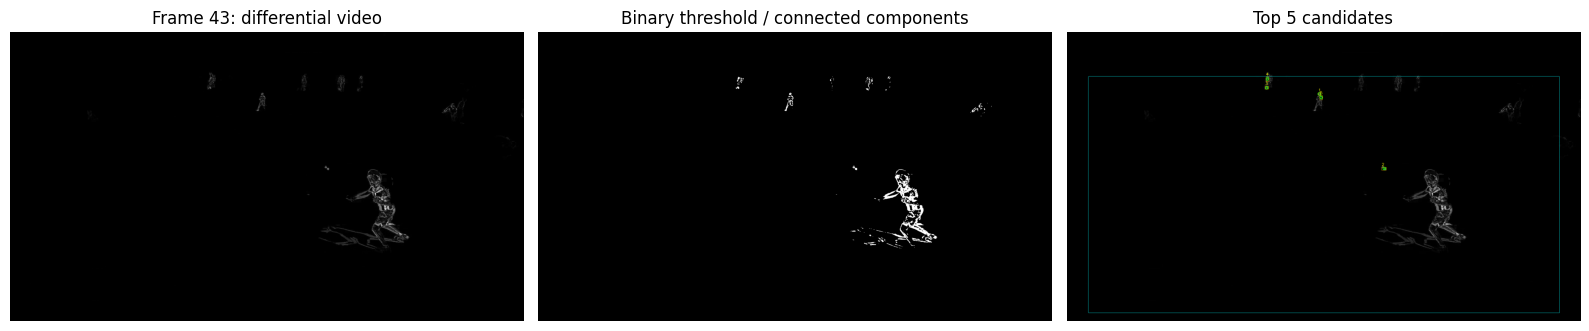

[{'label': 44,
  'centroid': (941.9310344827586, 230.86206896551724),
  'bbox': (938, 227, 9, 8),
  'area': 58,
  'aspect_ratio': 1.125,
  'circularity': 0.7973555973817124,
  'mean_brightness': 67.36206896551724,
  'max_brightness': 107,
  'score': 0.4656658924668384},
 {'label': 74,
  'centroid': (1184.7052631578947, 509.5684210526316),
  'bbox': (1175, 505, 17, 11),
  'area': 95,
  'aspect_ratio': 1.5454545454545454,
  'circularity': 0.379531978782691,
  'mean_brightness': 80.4421052631579,
  'max_brightness': 111,
  'score': 0.423266424052523},
 {'label': 36,
  'centroid': (745.8695652173913, 207.69565217391303),
  'bbox': (740, 202, 12, 11),
  'area': 69,
  'aspect_ratio': 1.0909090909090908,
  'circularity': 0.3601971687249082,
  'mean_brightness': 67.47826086956522,
  'max_brightness': 111,
  'score': 0.40651886943505816},
 {'label': 1,
  'centroid': (747.9186046511628, 175.03488372093022),
  'bbox': (743, 167, 11, 18),
  'area': 86,
  'aspect_ratio': 0.6111111111111112,
  'circ

In [27]:

frame_idx = 43
ball_diameter_px = 10.0

candidates, debug, overlay = show_ball_candidates_single_frame(
    diff_video_path=diff_video_path,
    frame_idx=frame_idx,
    ball_diameter_px=ball_diameter_px,
    top_k=5,
    diff_thresh=38,
    allowed_mask=allowed_mask,
    blur_ksize=3,
    morph_open=0,
    min_area_scale=0.15,
    max_area_scale=2.0,
    min_circularity=0.12,
    max_aspect_ratio_deviation=0.75,
    max_bbox_scale=2.0,
    min_mean_brightness=10,
)

candidates[:5]



## Create an annotated output video

This writes a new MP4 where the top 5 candidate ball locations are drawn on top of the differential video.


In [28]:

output_video_path = "ball_candidate_overlay.mp4"

result = create_ball_candidate_video(
    diff_video_path=diff_video_path,
    output_video_path=output_video_path,
    ball_diameter_px=ball_diameter_px,
    top_k=5,
    diff_thresh=28,
    allowed_mask=allowed_mask,
    blur_ksize=3,
    morph_open=0,
    min_area_scale=0.15,
    max_area_scale=2.0,
    min_circularity=0.12,
    max_aspect_ratio_deviation=0.75,
    max_bbox_scale=2.0,
    min_mean_brightness=10,
    codec="mp4v",
)

result


Processed 200 frames...


{'output_video_path': 'ball_candidate_overlay.mp4',
 'frames_written': 231,
 'fps': 24.99,
 'width': 1920,
 'height': 1080}


## Tuning notes

If you get lots of player-body false positives:
- lower `max_area_scale`
- lower `max_bbox_scale`
- increase `min_circularity`
- use an `allowed_mask`

If the ball is being missed:
- lower `diff_thresh`
- lower `min_circularity`
- widen `min_area_scale` / `max_area_scale`
- reduce or disable morphology

Useful debug path:
1. pick a frame where the ball is obvious
2. run `show_ball_candidates_single_frame(...)`
3. inspect the thresholded binary image
4. adjust diameter / threshold / shape filters until the ball reaches the top few candidates
